# Performing parity checks with mid-circuit measurements
**Using mid-circuit measurements to perform parity checks**

This tutorial demonstrates how to implement mid-circuit measurements (MCMs) to perform parity checks throughout a circuit's execution. A parity check, or parity measurement, allows you to verify the parity of multiple qubits to detect errors without collapsing the quantum state of the primary data qubits.

To execute a simple three-qubit code parity check, an ancillary qubit is used as the subject of measurement. By performing controlled-NOT (CNOT) gates on the ancillary qubit dependent on the other two qubits and then performing a measurment, we can determine if the qubits are in the same state or not. This type of parity check is an essential concept in the implementation of Quantum Error Correction (QEC).

As you implement more complex algorithms, such as QEC, Fire Opal can act as an essential tool for reducing hardware error that arises during circuit execution and worsens as circuits get larger.

In this tutorial you will:
* Create a circuit with mid-circuit measurements
* Run the circuit on a simulator and evaluate mid-circuit and final measurements
* Run the circuit on a real device with Fire Opal
* Run the circuit on a real device without Fire Opal
* Compare final measurements across each of the executions

The goal is to validate that the mid-circuit measurements performed correctly across all three executions, according to the expected outcomes of the parity checks, and to compare the benefits of executing circuits with mid-circuit measurements to suppress noise.

## 1. Import packages and set up your credentials

You'll first need to install and import the packages used in this tutorial. To do so, run this script in your command line or terminal:

```shell
pip install fire-opal, qiskit, pylatexenc, qiskit-aer, qiskit-ibm-runtime
```

In [35]:
import fireopal as fo
import qiskit
import numpy as np
from qiskit_aer import AerSimulator
from qiskit_ibm_runtime import QiskitRuntimeService

To create your credentials, input your IBM API key and Cloud Resource Name (CRN) found within your IBM Cloud account. See the [Onboarding guide for the new IBM Quantum Platform](https://quantum.cloud.ibm.com/docs/en/migration-guides/classic-iqp-to-cloud-iqp#onboard) for more details.

In [ ]:
token = "YOUR_IBM_CLOUD_API_KEY"
instance = "YOUR_IBM_CRN"

credentials = fo.credentials.make_credentials_for_ibm_cloud(
    token=token, instance=instance
)

## 2. Choose a backend

In [ ]:
supported_devices = fo.show_supported_devices(credentials=credentials)[
    "supported_devices"
]

for name in supported_devices:
    print(name)

In [ ]:
backend_name = "SELECT_BACKEND_FROM_ABOVE"

## 3. Define helper functions

These helper functions will be used to adjust the results for plotting and output purposes.

In [57]:
def get_prob_from_qubit_trace(counts, bit_index, shot_count, expected_measurement):
    """Return the probability between 0 and 100."""
    correct_outcome = 0
    for key in counts:
        if key[bit_index] == expected_measurement:
            correct_outcome += counts[key]
    return 100 * correct_outcome / shot_count


def print_parity_check_results(counts, shot_count):
    """
    Check the values of the mid-circuit measurements to compare to the expected values: 0, 1, 1.
    Since the mid-circuit measurements are listed to the left and in reverse order (qiskit ordering)
    we expect the 0th bitstring position to be 0, the 1st to be 1, and 2nd to be 1, each with 100% probability.
    """
    qiskit_ordering_map = {0: "2", 1: "1", 2: "0"}
    expected_measurement_map = {"0": "1", "1": "1", "2": "0"}
    for check_index in range(3):
        print(
            f"\nParity check #{check_index+1}\n"
            f"We expect to see mid-circuit measurement {qiskit_ordering_map[check_index]} = '{expected_measurement_map[str(check_index)]}' with 100% probability\n"
            f"It was measured to be '{expected_measurement_map[str(check_index)]}' with probability "
            f"{np.round(get_prob_from_qubit_trace(counts, check_index, shot_count, expected_measurement_map[str(check_index)]), 1)}%"
        )

## 4. Define the circuit
For this parity check, three qubits will be used, and the mid-circuit and final measurements will be stored in different classical registers. Note that if different memory registers are not defined for mid- and end-circuit measurements, the mid-circuit measurements will be overwritten.

This circuit, will involve creating a Bell pair entangled state $\frac{1}{\sqrt{2}}( \lvert 00 \rangle + \lvert 11 \rangle)$ on the first two qubits, while parity checking these two qubits (q0,q1) through two CNOT operations on a third ancilla qubit ($q2=q0 \oplus  q1$). In the first case, measuring q2 will yield the state '0' if the Bell state is prepared perfectly. The circuit will also perform parity checks on two other consecutive states synthetically corrupted, first corrupting q0 with an X gate and parity checking, and lastly corrupting q1 with an X gate and parity checking. The second parity check measurement on q2 should yield the value '1' after the first corruption, and then the final parity check on q2 should again be unchanged and remain as '1'.

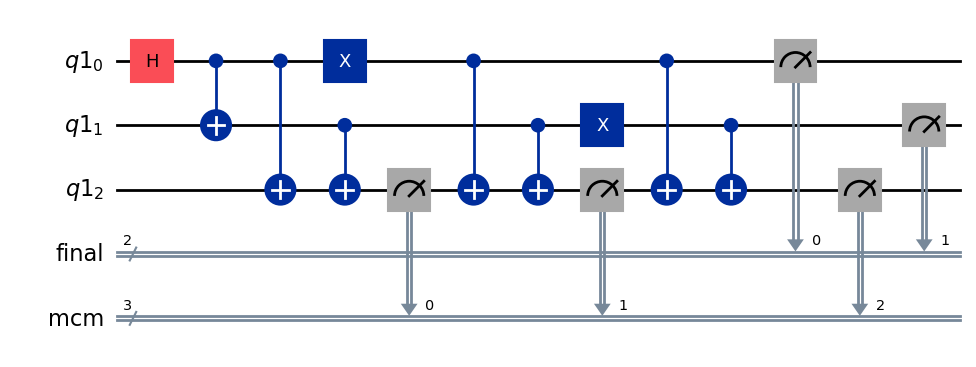

In [38]:
qubit_count = 3
shot_count = 1024

quantum_register = qiskit.QuantumRegister(qubit_count)
final_measurement_reg = qiskit.ClassicalRegister(2, "final")
mid_circuit_measurement_reg = qiskit.ClassicalRegister(3, "mcm")

qc = qiskit.QuantumCircuit(
    quantum_register, final_measurement_reg, mid_circuit_measurement_reg
)

# Create a Bell pair entangled state between qubits 0 and 1.
qc.h(0)
qc.cx(0, 1)

# Perform a parity check.
qc.cx(0, 2)
qc.cx(1, 2)
qc.measure(2, mid_circuit_measurement_reg[0])

# Deliberately add error to change the state of qubit 0.
qc.x(0)

# Perform a parity check.
qc.cx(0, 2)
qc.cx(1, 2)
qc.measure(2, mid_circuit_measurement_reg[1])

# Deliberately add error to change the state of qubit 1.
qc.x(1)

# Perform a parity check.
qc.cx(0, 2)
qc.cx(1, 2)
qc.measure(2, mid_circuit_measurement_reg[2])

qc.measure(0, final_measurement_reg[0])
qc.measure(1, final_measurement_reg[1])

qc.draw("mpl", fold=-1)

## 5. Run the circuit on a simulator

First, the circuit will be run on a simulator to verify the expected outcomes of the three mid-circuit measurements and the results at final measurement.

In [39]:
simulation_jobs = AerSimulator(method="statevector").run(qc, shots=shot_count)
simulation_counts = qiskit.result.marginal_counts(simulation_jobs.result()).get_counts()
print("Simulated counts:", simulation_counts)

Simulated counts: {'110 00': 509, '110 11': 515}


In [58]:
print_parity_check_results(simulation_counts, shot_count)


Parity check #1
We expect to see mid-circuit measurement 2 = '1' with 100% probability
It was measured to be '1' with probability 100.0%

Parity check #2
We expect to see mid-circuit measurement 1 = '1' with 100% probability
It was measured to be '1' with probability 100.0%

Parity check #3
We expect to see mid-circuit measurement 0 = '0' with 100% probability
It was measured to be '0' with probability 100.0%


## 6. Run the circuit using Fire Opal
Next, the circuit will be run with Fire Opal to suppress hardware errors during execution.

**Note: Fire Opal mitigates both the mid-circuit as well as the final measurements in post-processing to provide you with the optimal end results. This mitigation does not impact the values of the the mid-circuit measurements.**

In [ ]:
from qiskit.qasm2 import dumps

qasm_circuit = dumps(qc)
fire_opal_job = fo.execute(
    circuits=qasm_circuit,
    shot_count=shot_count,
    credentials=credentials,
    backend_name=backend_name,
)

In [ ]:
fire_opal_results = fire_opal_job.result()

In [ ]:
mid_measurements = fire_opal_results["execution_results"][0]["mcm"]
final_measurements = fire_opal_results["execution_results"][0]["final"]

In [44]:
fire_opal_mid_counts = {
    bitstring: int(probability * shot_count)
    for bitstring, probability in mid_measurements.items()
}
print("Fire Opal mid-circuit measurement counts:", fire_opal_mid_counts)

Fire Opal mid-circuit measurement counts: {'000': 6, '001': 10, '010': 22, '011': 7, '100': 26, '110': 950}


In [45]:
fire_opal_final_counts = {
    bitstring: int(probability * shot_count)
    for bitstring, probability in final_measurements.items()
}

print("Fire Opal final measurement counts:", fire_opal_final_counts)

Fire Opal final measurement counts: {'00': 486, '01': 24, '10': 48, '11': 463}


In [59]:
print_parity_check_results(fire_opal_mid_counts, shot_count)


Parity check #1
We expect to see mid-circuit measurement 2 = '1' with 100% probability
It was measured to be '1' with probability 95.3%

Parity check #2
We expect to see mid-circuit measurement 1 = '1' with 100% probability
It was measured to be '1' with probability 95.6%

Parity check #3
We expect to see mid-circuit measurement 0 = '0' with 100% probability
It was measured to be '0' with probability 98.0%


## 7. Run the circuit without Fire Opal
Finally, the circuit will be executed on the same bare metal IBM device, but without the use of Fire Opal to suppress hardware error.

In [ ]:
from qiskit_ibm_runtime import SamplerV2 as Sampler
from qiskit.transpiler.preset_passmanagers import generate_preset_pass_manager

service = QiskitRuntimeService(
    token=token, instance=instance, channel="ibm_quantum_platform"
)
backend = service.backend(backend_name)
sampler = Sampler(backend)

pass_manager = generate_preset_pass_manager(backend=backend)
isa_circuit = pass_manager.run(qc)
ibm_result = sampler.run([isa_circuit], shots=shot_count).result()

In [55]:
ibm_mcm_counts = ibm_result[0].data.mcm.get_counts()
print("Without Fire Opal mid-circuit measurement counts:", ibm_mcm_counts)

Without Fire Opal mid-circuit measurement counts: {'010': 44, '110': 916, '011': 20, '100': 23, '000': 13, '111': 5, '101': 1, '001': 2}


In [60]:
print_parity_check_results(ibm_mcm_counts, shot_count)


Parity check #1
We expect to see mid-circuit measurement 2 = '1' with 100% probability
It was measured to be '1' with probability 92.3%

Parity check #2
We expect to see mid-circuit measurement 1 = '1' with 100% probability
It was measured to be '1' with probability 96.2%

Parity check #3
We expect to see mid-circuit measurement 0 = '0' with 100% probability
It was measured to be '0' with probability 97.3%


As you can see, all three executions yielded results similar to our expected values, but the final probabilities obtained from the run with Fire Opal more closely match the expected outcomes of the parity checks than the run without Fire Opal.

When executing complex algorithms that use advanced features like mid-circuit measurement, Fire Opal can crucially suppress noise that is correlated with algorithm complexity.